In [31]:
import geopandas as gpd
import pandas as pd

# display all columns
pd.set_option('display.max_columns', None)

TARGET = 'orgc'

# load the dataset
gdf = gpd.read_file(f'D:/tierra/datasets/mexico_{TARGET}_dataset_add_soil_features.geojson')

if TARGET == 'orgc':
    gdf.drop(columns=['tceq'], axis=1, inplace=True, errors='ignore')
elif TARGET == 'tceq':
    gdf.drop(columns=['orgc'], axis=1, inplace=True, errors='ignore')

gdf.head()

,date,longitude,latitude,upper_depth,lower_depth,clay,elcosp,orgc,phaq,sand,silt,temperature,precipitation,landcover,ecoregion,slopemean,soil_type,bedrock,rock_fragments,geometry
0,5/3/2001,-115.41731,30.06335,0,10,27.0,0.1,9.0,7.6,51.0,22.0,16.512228,83.567986,9.0,5,1.016612,VERTISOL CROMICO,rocas_sedimentarias,8.892663,POINT (-115.41731 30.06335)
1,5/3/2001,-115.41731,30.06335,0,10,27.0,0.1,9.0,7.6,51.0,22.0,16.512228,83.567986,9.0,5,1.016612,VERTISOL CROMICO,rocas_sedimentarias,7.844637,POINT (-115.41731 30.06335)
2,5/3/2001,-115.41731,30.06335,0,10,27.0,0.1,9.0,7.6,51.0,22.0,16.512228,83.567986,9.0,5,1.016612,VERTISOL CROMICO,rocas_sedimentarias,7.844637,POINT (-115.41731 30.06335)
3,5/3/2001,-115.41731,30.06335,0,10,27.0,0.1,9.0,7.6,51.0,22.0,16.512228,83.567986,9.0,5,1.016612,VERTISOL CROMICO,rocas_sedimentarias,8.892663,POINT (-115.41731 30.06335)
4,5/3/2001,-115.41731,30.06335,0,10,27.0,0.1,9.0,7.6,51.0,22.0,16.512228,83.567986,9.0,5,1.016612,VERTISOL CROMICO,rocas_sedimentarias,7.844637,POINT (-115.41731 30.06335)


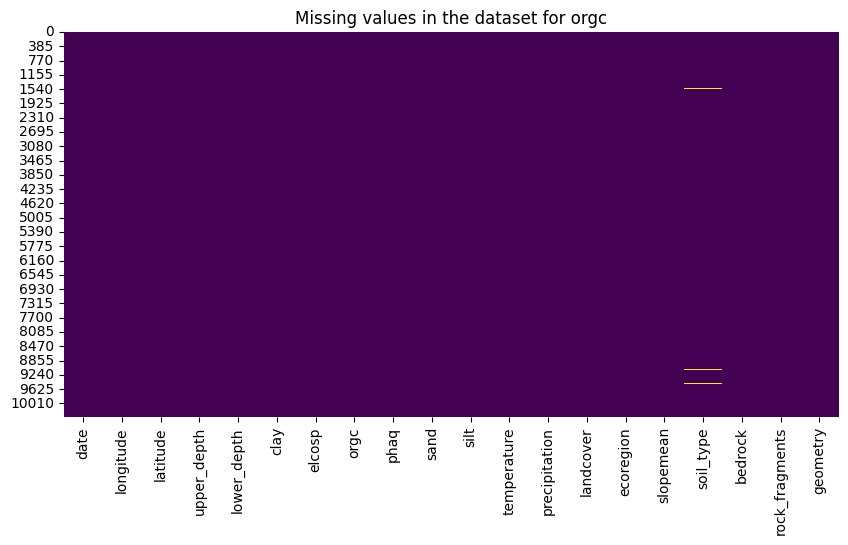

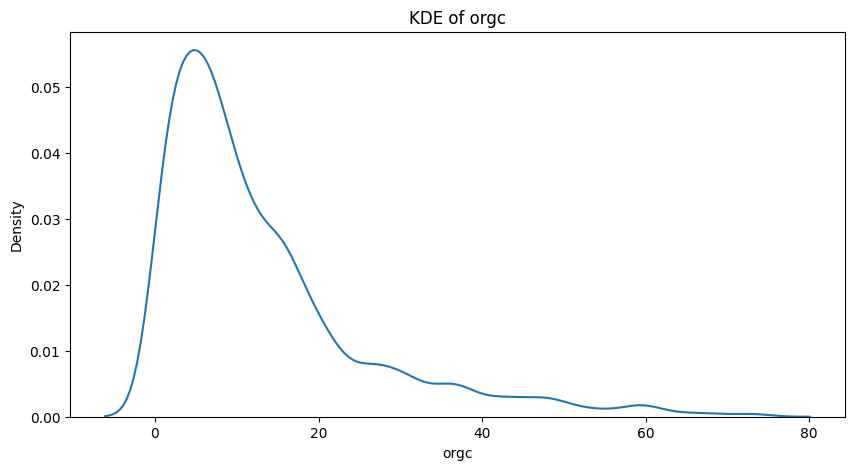

In [32]:
# plot missing values in the dataset
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))
sns.heatmap(gdf.isnull(), cbar=False, cmap='viridis')
plt.title(f'Missing values in the dataset for {TARGET}')
plt.show()

# plot kde of the target variable
plt.figure(figsize=(10, 5))
sns.kdeplot(gdf[TARGET])
plt.title(f'KDE of {TARGET}')
plt.show()

In [33]:
# drop rows with missing values
gdf.dropna(inplace=True)
print('After dropping rows with missing values:', gdf.shape)
# drop duplicate rows
gdf.drop_duplicates(inplace=True)
print('After dropping duplicate rows:', gdf.shape)

After dropping rows with missing values: (10299, 20)
After dropping duplicate rows: (5963, 20)


In [35]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# Drop irrelevant columns
gdf.drop(columns=['date', 'latitude', 'longitude', 'geometry'], inplace=True, errors='ignore')

def preprocess_data(data, target=None, categorical_cols=None, label_cols=None, is_train=True, encoders=None):
    """
    Preprocess data with proper encoding and handling of categorical variables
    
    Args:
        data: Input DataFrame
        target: Target variable name
        categorical_cols: List of columns for one-hot encoding
        label_cols: List of columns for label encoding
        is_train: Boolean indicating if this is training data
        encoders: Dictionary of fitted label encoders (for test data)
        
    Returns:
        Preprocessed features, target (if provided), and encoders dictionary
    """
    # Create a copy to avoid modifying original data
    df = data.copy()
    
    # Initialize encoders dictionary if not provided
    if encoders is None:
        encoders = {}
    
    # Label encoding
    if label_cols:
        for col in label_cols:
            if is_train:
                encoders[col] = LabelEncoder()
                df[col] = encoders[col].fit_transform(df[col])
            else:
                df[col] = encoders[col].transform(df[col])
    
    # One-hot encoding
    if categorical_cols:
        df = pd.get_dummies(df, columns=categorical_cols, drop_first=True, dtype='int8')
    
    # Split features and target
    if target and target in df.columns:
        y = df[target]
        X = df.drop(target, axis=1)
        return X, y, encoders
    
    return df, None, encoders

# Define categorical columns
categorical_cols = ['landcover', 'ecoregion']
label_cols = ['soil_type', 'bedrock']

# First split data to prevent data leakage
train_df, test_df = train_test_split(gdf, test_size=0.2, random_state=42, shuffle=True)

# Preprocess training data
X_train, y_train, encoders = preprocess_data(
    train_df, 
    target=TARGET,
    categorical_cols=categorical_cols,
    label_cols=label_cols,
    is_train=True
)

# Preprocess test data using encodings learned from training data
X_test, y_test, _ = preprocess_data(
    test_df,
    target=TARGET,
    categorical_cols=categorical_cols,
    label_cols=label_cols,
    is_train=False,
    encoders=encoders
)

# Ensure test set has all columns from training set
missing_cols = set(X_train.columns) - set(X_test.columns)
for col in missing_cols:
    X_test[col] = 0
X_test = X_test[X_train.columns]

print('Training set shape:', X_train.shape)
print('Test set shape:', X_test.shape)

Training set shape: (4770, 32)
Test set shape: (1193, 32)


In [28]:
# df = train_df.copy()
# uncomment for testing purposes
# df.drop(columns=['soil_type', 'bedrock', 'rock_fragments', 'slopemean'], inplace=True)


Training Random Forest...
MSE: 27.1257
MAE: 3.2784
R2: 0.8236


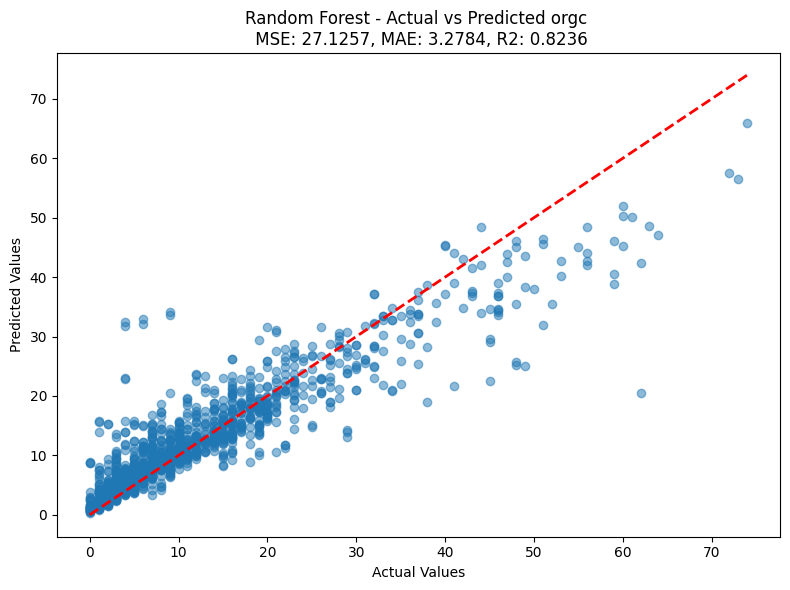

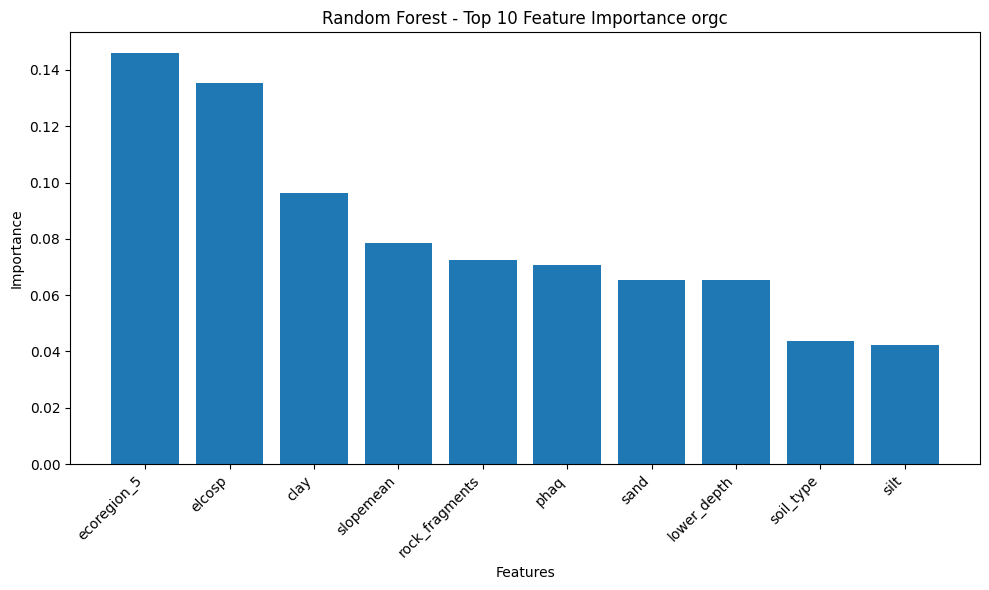


Training Gradient Boosting...
MSE: 68.9734
MAE: 5.6682
R2: 0.5516


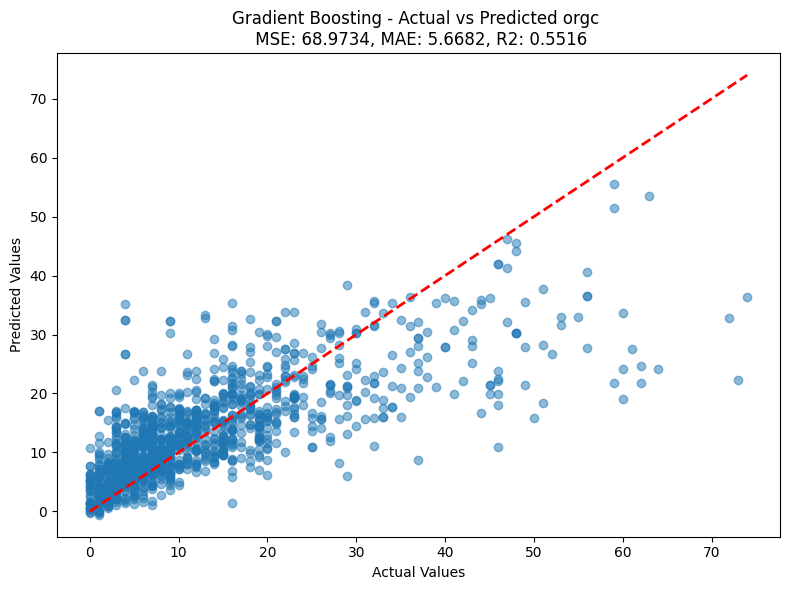

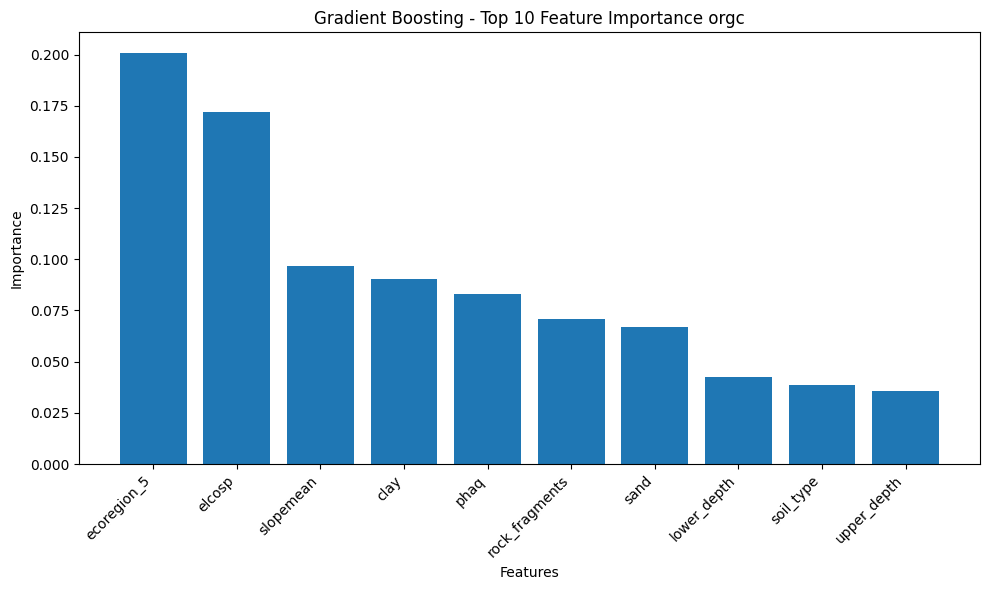


Training MLP...
MSE: 76.9691
MAE: 5.9845
R2: 0.4996


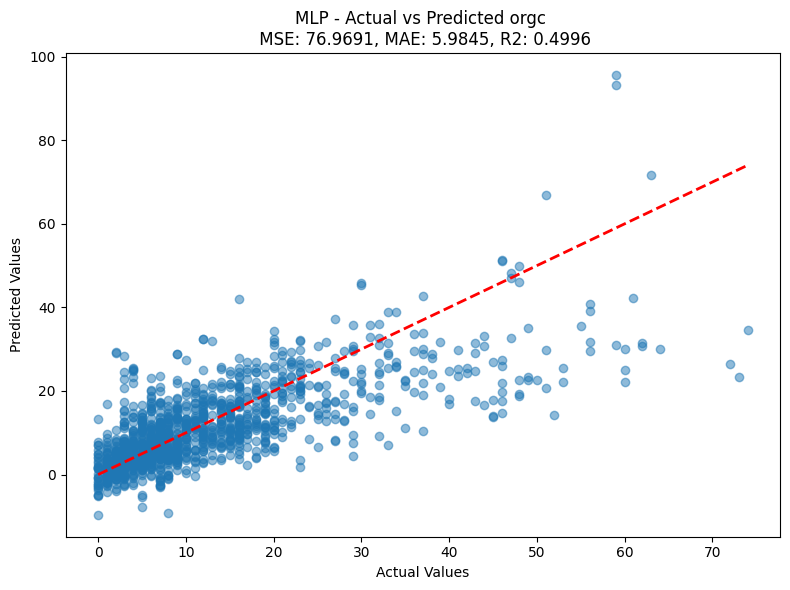

In [36]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt

# Initialize models
models = {
    'Random Forest': RandomForestRegressor(random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42),
    'MLP': MLPRegressor(random_state=42, max_iter=1000)
}

# Train and evaluate models
for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train, y_train)
    
    # Make predictions
    y_pred = model.predict(X_test)
    
    # Calculate metrics
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    print(f"MSE: {mse:.4f}")
    print(f"MAE: {mae:.4f}")
    print(f"R2: {r2:.4f}")
    
    # Plot actual vs predicted
    plt.figure(figsize=(8, 6))
    plt.scatter(y_test, y_pred, alpha=0.5)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
    plt.xlabel('Actual Values')
    plt.ylabel('Predicted Values')
    plt.title(f'{name} - Actual vs Predicted {TARGET} \n MSE: {mse:.4f}, MAE: {mae:.4f}, R2: {r2:.4f}')
    plt.tight_layout()
    plt.show()
    
    # Plot feature importance for tree-based models
    if name in ['Random Forest', 'Gradient Boosting']:
        importance = model.feature_importances_
        feat_importance = pd.DataFrame({
            'feature': X_train.columns,
            'importance': importance
        }).sort_values('importance', ascending=False)
        
        plt.figure(figsize=(10, 6))
        plt.bar(range(10), feat_importance['importance'][:10])
        plt.xticks(range(10), feat_importance['feature'][:10], rotation=45, ha='right')
        plt.xlabel('Features')
        plt.ylabel('Importance')
        plt.title(f'{name} - Top 10 Feature Importance {TARGET}')
        plt.tight_layout()
        plt.show()



Tuning Random Forest...
Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best parameters: {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 300}
Best CV score: 0.7548

Tuning Gradient Boosting...
Fitting 5 folds for each of 27 candidates, totalling 135 fits
Best parameters: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 300}
Best CV score: 0.8032

Tuning MLP...
Fitting 5 folds for each of 18 candidates, totalling 90 fits
Best parameters: {'alpha': 0.01, 'hidden_layer_sizes': (100, 100), 'learning_rate': 'constant'}
Best CV score: 0.5219

Evaluating tuned models with cross-validation...

Random Forest CV Results:
Mean R2: 0.7548 (+/- 0.0501)
Test MSE: 26.7867
Test MAE: 3.2725
Test R2: 0.8258


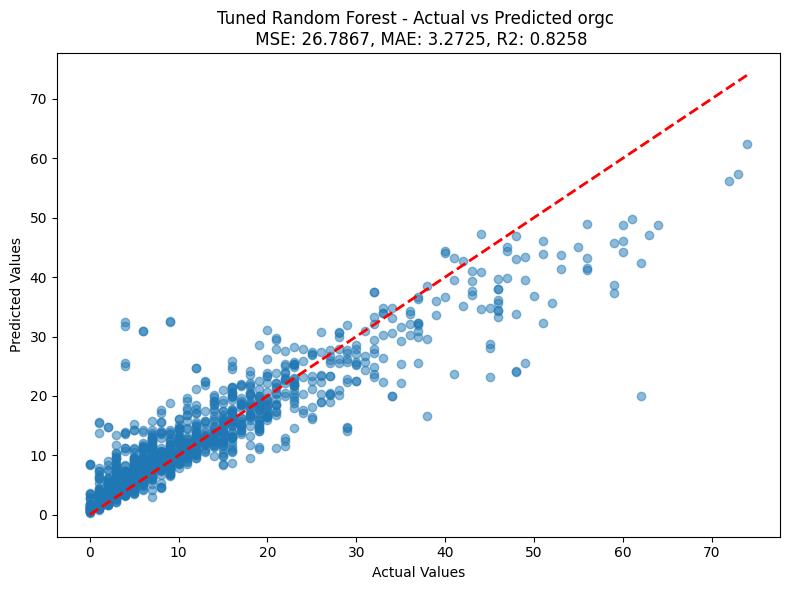

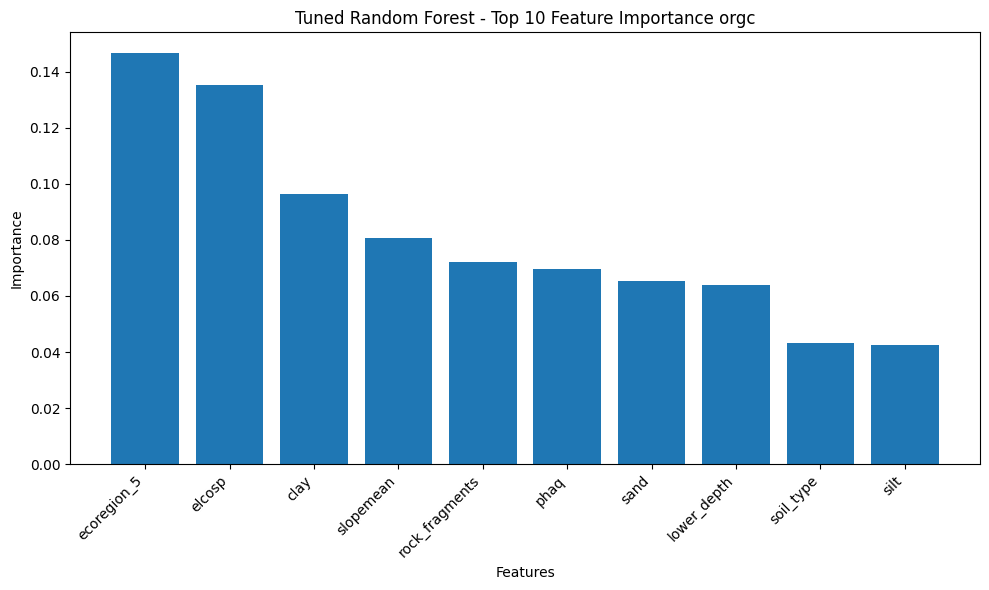


Gradient Boosting CV Results:
Mean R2: 0.8032 (+/- 0.0391)
Test MSE: 18.5264
Test MAE: 2.4801
Test R2: 0.8795


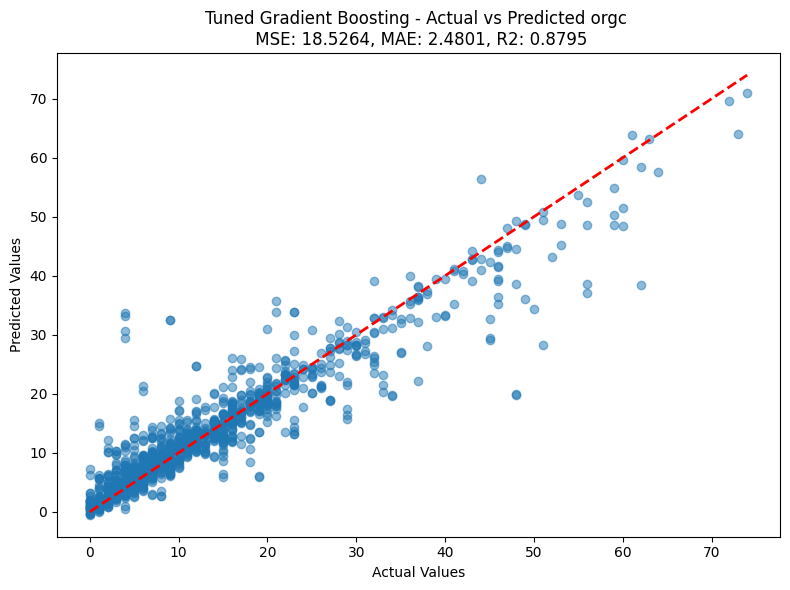

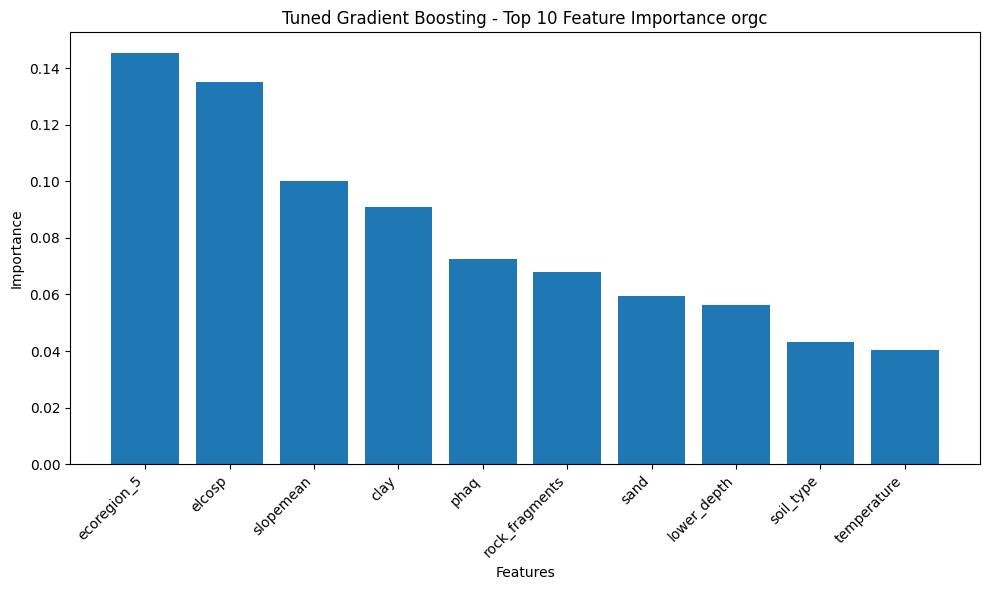


MLP CV Results:
Mean R2: 0.5219 (+/- 0.0635)
Test MSE: 60.3990
Test MAE: 5.6433
Test R2: 0.6073


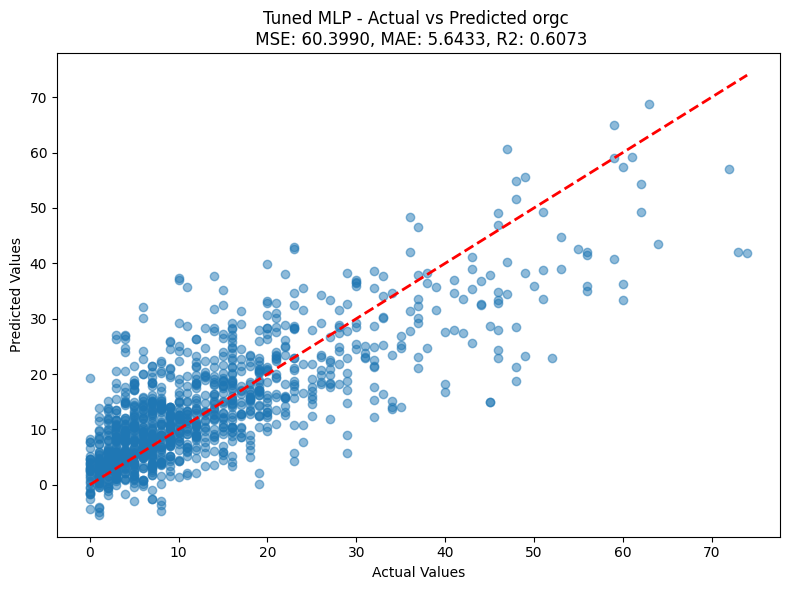

In [30]:
from sklearn.model_selection import GridSearchCV, cross_val_score

# Define parameter grids for each model
rf_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10]
}

gb_param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.1, 0.3],
    'max_depth': [3, 5, 7]
}

mlp_param_grid = {
    'hidden_layer_sizes': [(50,50), (100,50), (100,100)],
    'alpha': [0.0001, 0.001, 0.01],
    'learning_rate': ['constant', 'adaptive']
}

# Perform Grid Search with 5-fold CV
cv = 5
tuned_models = {}

# Random Forest
print("\nTuning Random Forest...")
rf_grid = GridSearchCV(RandomForestRegressor(random_state=42), 
                      rf_param_grid, cv=cv, n_jobs=-1, verbose=1)
rf_grid.fit(X_train, y_train)
tuned_models['Random Forest'] = rf_grid.best_estimator_
print(f"Best parameters: {rf_grid.best_params_}")
print(f"Best CV score: {rf_grid.best_score_:.4f}")

# Gradient Boosting
print("\nTuning Gradient Boosting...")
gb_grid = GridSearchCV(GradientBoostingRegressor(random_state=42),
                      gb_param_grid, cv=cv, n_jobs=-1, verbose=1)
gb_grid.fit(X_train, y_train)
tuned_models['Gradient Boosting'] = gb_grid.best_estimator_
print(f"Best parameters: {gb_grid.best_params_}")
print(f"Best CV score: {gb_grid.best_score_:.4f}")

# MLP
print("\nTuning MLP...")
mlp_grid = GridSearchCV(MLPRegressor(random_state=42, max_iter=1000),
                       mlp_param_grid, cv=cv, n_jobs=-1, verbose=1)
mlp_grid.fit(X_train, y_train)
tuned_models['MLP'] = mlp_grid.best_estimator_
print(f"Best parameters: {mlp_grid.best_params_}")
print(f"Best CV score: {mlp_grid.best_score_:.4f}")

# Evaluate tuned models
print("\nEvaluating tuned models with cross-validation...")
for name, model in tuned_models.items():
    cv_scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='r2')
    print(f"\n{name} CV Results:")
    print(f"Mean R2: {cv_scores.mean():.4f} (+/- {cv_scores.std()*2:.4f})")
    
    # Make predictions
    y_pred = model.predict(X_test)
    
    # Calculate metrics
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    print(f"Test MSE: {mse:.4f}")
    print(f"Test MAE: {mae:.4f}")
    print(f"Test R2: {r2:.4f}")
    
    # Plot actual vs predicted
    plt.figure(figsize=(8, 6))
    plt.scatter(y_test, y_pred, alpha=0.5)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
    plt.xlabel('Actual Values')
    plt.ylabel('Predicted Values')
    plt.title(f'Tuned {name} - Actual vs Predicted {TARGET} \n MSE: {mse:.4f}, MAE: {mae:.4f}, R2: {r2:.4f}')
    plt.tight_layout()
    plt.show()
    
    # Plot feature importance for tree-based models
    if name in ['Random Forest', 'Gradient Boosting']:
        importance = model.feature_importances_
        feat_importance = pd.DataFrame({
            'feature': X_train.columns,
            'importance': importance
        }).sort_values('importance', ascending=False)
        
        plt.figure(figsize=(10, 6))
        plt.bar(range(10), feat_importance['importance'][:10])
        plt.xticks(range(10), feat_importance['feature'][:10], rotation=45, ha='right')
        plt.xlabel('Features')
        plt.ylabel('Importance')
        plt.title(f'Tuned {name} - Top 10 Feature Importance {TARGET}')
        plt.tight_layout()
        plt.show()